# Signal Processing and Feature Extraction

This notebook documents the signal processing and feature matrix used by the classical machine learning models.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.features.extract_features import extract_features, save_feature_outputs
from src.features.signal_processing import butterworth_filter

pd.set_option("display.max_columns", 50)

## Load processed splits

In [2]:
x_train = np.load(config.X_TRAIN_RAW_NPY)
y_train = np.load(config.Y_TRAIN_NPY)
x_val = np.load(config.X_VAL_RAW_NPY)
y_val = np.load(config.Y_VAL_NPY)
x_test = np.load(config.X_TEST_RAW_NPY)
y_test = np.load(config.Y_TEST_NPY)

pd.DataFrame(
    [
        {"split": "train", "rows": x_train.shape[0], "time_steps": x_train.shape[1]},
        {"split": "validation", "rows": x_val.shape[0], "time_steps": x_val.shape[1]},
        {"split": "test", "rows": x_test.shape[0], "time_steps": x_test.shape[1]},
    ]
)

,split,rows,time_steps
0,train,70043,187
1,validation,17511,187
2,test,21892,187


The raw MIT-BIH segments are already scaled to [0, 1]. For classical features, the extraction function applies a light Butterworth band-pass filter before computing summary features. The CNN path can still compare raw scaled inputs and per-beat z-score inputs.

## Filter preview

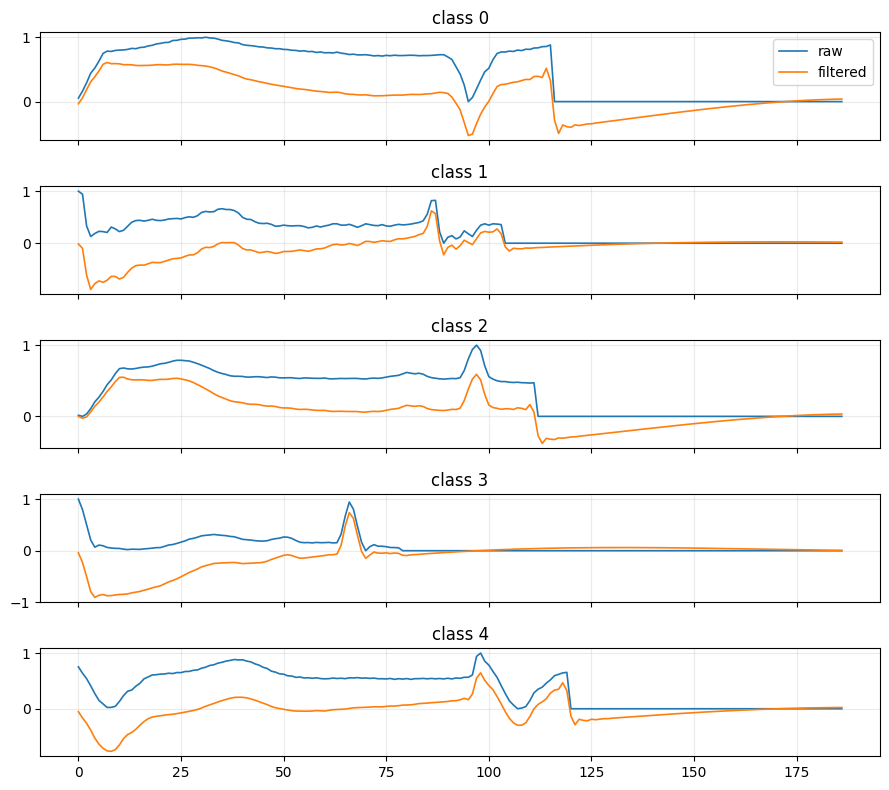

In [3]:
example_indices = [np.flatnonzero(y_train == label)[0] for label in sorted(np.unique(y_train))]
examples = x_train[example_indices]
filtered_examples = butterworth_filter(examples)

fig, axes = plt.subplots(len(example_indices), 1, figsize=(9, 8), sharex=True)
for ax, label, raw, filtered in zip(axes, sorted(np.unique(y_train)), examples, filtered_examples):
    ax.plot(raw, label="raw", linewidth=1.2)
    ax.plot(filtered, label="filtered", linewidth=1.2)
    ax.set_title(f"class {label}")
    ax.grid(alpha=0.25)
axes[0].legend(loc="upper right")
fig.tight_layout()

## Build feature matrices

In [4]:
save_feature_outputs()

Feature matrix summary
     split  rows  features
     train 70043        29
validation 17511        29
      test 21892        29

Feature count: 29


In [5]:
features_train = np.load(config.FEATURES_TRAIN_NPY)
features_val = np.load(config.FEATURES_VAL_NPY)
features_test = np.load(config.FEATURES_TEST_NPY)
feature_names = config.FEATURE_NAMES_TXT.read_text(encoding="utf-8").splitlines()

pd.DataFrame(
    [
        {"split": "train", "rows": features_train.shape[0], "features": features_train.shape[1]},
        {"split": "validation", "rows": features_val.shape[0], "features": features_val.shape[1]},
        {"split": "test", "rows": features_test.shape[0], "features": features_test.shape[1]},
    ]
)

,split,rows,features
0,train,70043,29
1,validation,17511,29
2,test,21892,29


In [6]:
pd.DataFrame({"feature": feature_names})

,feature
0,mean
1,std
2,min
3,max
4,range
5,q25
6,median
7,q75
8,skew
9,kurtosis


## Feature sanity checks

In [7]:
feature_quality = pd.DataFrame(
    {
        "feature": feature_names,
        "train_mean": features_train.mean(axis=0),
        "train_std": features_train.std(axis=0),
        "has_nan": np.isnan(features_train).any(axis=0),
        "has_inf": np.isinf(features_train).any(axis=0),
    }
)
feature_quality

,feature,train_mean,train_std,has_nan,has_inf
0,mean,-0.083254,0.049959,False,False
1,std,0.254692,0.043206,False,False
2,min,-0.817510,0.165310,False,False
3,max,0.771485,0.172512,False,False
4,range,1.589007,0.274911,False,False
5,q25,-0.175981,0.057671,False,False
6,median,-0.010537,0.027433,False,False
7,q75,0.045522,0.061492,False,False
8,skew,-0.532065,0.593970,False,False
9,kurtosis,2.174083,1.664095,False,False


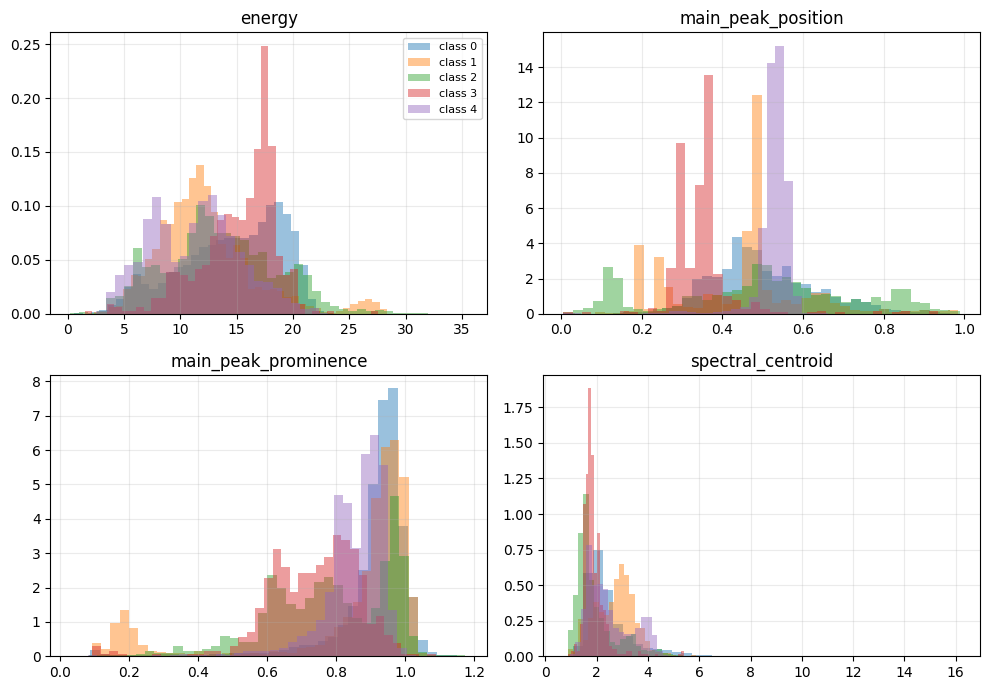

In [8]:
selected = ["energy", "main_peak_position", "main_peak_prominence", "spectral_centroid"]
selected_idx = [feature_names.index(name) for name in selected]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for ax, name, idx in zip(axes, selected, selected_idx):
    for label in sorted(np.unique(y_train)):
        values = features_train[y_train == label, idx]
        ax.hist(values, bins=40, alpha=0.45, density=True, label=f"class {label}")
    ax.set_title(name)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
fig.tight_layout()

## Notes

The feature set is intentionally modest: 15 time-domain features, 8 frequency-domain features, and 6 shape/autocorrelation features. These features should give classical models a fair baseline, but they are not expected to capture all morphology details available to a 1-D CNN.